In [1]:
import logging
logging.getLogger().setLevel(logging.ERROR)
import os
import sys
os.environ['PYTHONWARNINGS'] = 'ignore'
class NullWriter:
    def write(self, msg):
        pass
    def flush(self):
        pass
sys.stderr = NullWriter()

In [2]:
import scanpy as sc, matplotlib.pyplot as plt, numpy as np, celldyc as cdc

In [ ]:
adata = cdc.datasets.zebrafish()
#adata = sc.read_h5ad('zebrafish.h5ad') 
adata

AnnData object with n_obs × n_vars = 2341 × 23974
    obs: 'Stage', 'gt_terminal_states', 'lineages'
    uns: 'Stage_colors', 'gt_terminal_states_colors', 'lineages_colors'
    obsm: 'X_force_directed'

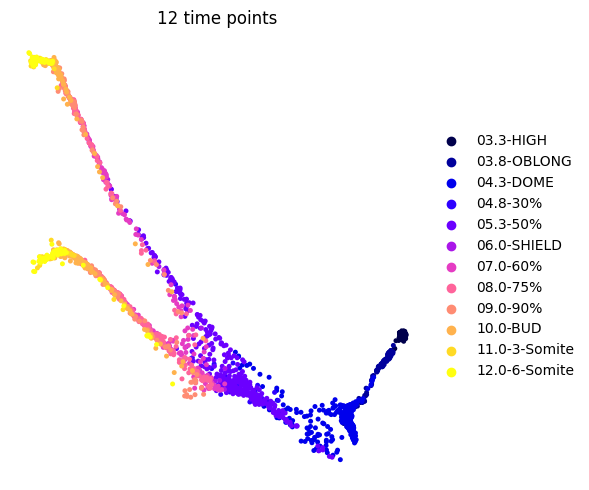

Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.837947,trend_loss=0.828511,time_loss=0.094358
epoch  51:loss=0.425178,trend_loss=0.424160,time_loss=0.010178
epoch 101:loss=0.385324,trend_loss=0.384423,time_loss=0.009003
epoch 151:loss=0.377774,trend_loss=0.376906,time_loss=0.008671
epoch 201:loss=0.373027,trend_loss=0.372226,time_loss=0.008010
epoch 251:loss=0.352568,trend_loss=0.351829,time_loss=0.007390
Early stopping at epoch 299


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


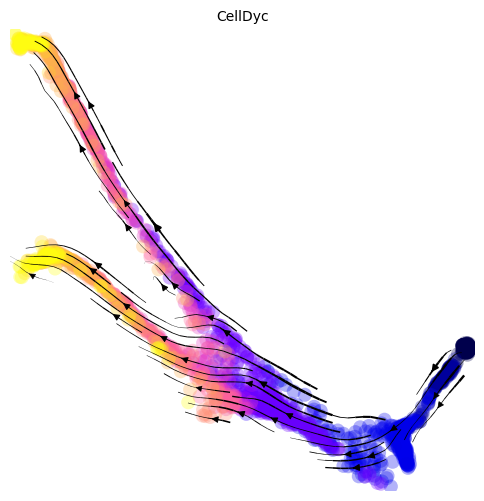

computing velocity embedding
finished.


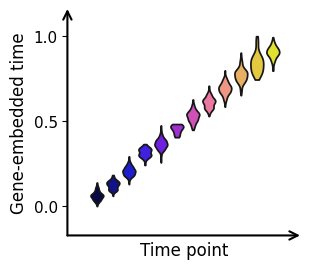

<Axes: xlabel='Time point', ylabel='Gene-embedded time'>

In [7]:
cat_map = {'03.3-HIGH': 03.3,
           '03.8-OBLONG': 03.8,
           '04.3-DOME': 04.3,
           '04.8-30%':04.8,
           '05.3-50%':05.3,
           '06.0-SHIELD':06.0,
           '07.0-60%':07.0,
           '08.0-75%':08.0,
           '09.0-90%':09.0,
           '10.0-BUD':10.0,
           '11.0-3-Somite':11.0,
           '12.0-6-Somite':12.0}
adata.obs['numerical_time'] = adata.obs['Stage'].map(cat_map).astype('category')
fig, ax = plt.subplots(figsize=(6,5))
sc.pl.embedding(adata, color="Stage", basis="force_directed",
                color_map="gnuplot2", show=False, ax=ax,
                title="12 time points")
ax.set_xlabel(""); ax.set_ylabel("")
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout(); plt.show()
adata = cdc.tl.preprocess(adata)
adata_wot=adata.copy()
adata_moscot=adata.copy()
cdc.tl.recover_dyc(adata, time_key='numerical_time')
cdc.pl.plot_velocity_projection(adata,
        basis='force_directed', color='Stage', legend_loc='none',
        figsize=(6,6), title="CellDyc")
cdc.pl.getime_violin(adata, 'getime', 'numerical_time',palette='gnuplot2')


computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


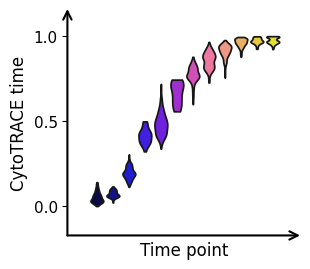

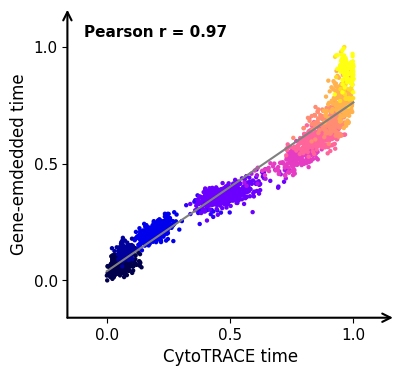

In [ ]:
import cellrank as cr, scvelo as scv
adata_ct = cdc.datasets.zebrafish()
adata_ct = adata_ct[~np.isnan(adata_ct.obsm['X_force_directed']).any(1)].copy()
sc.pp.filter_genes(adata_ct, min_cells=10)
sc.pp.normalize_total(adata_ct)
sc.pp.log1p(adata_ct)
sc.pp.highly_variable_genes(adata_ct)
adata_ct.layers['spliced'] = adata_ct.X
adata_ct.layers['unspliced'] = adata_ct.X
scv.pp.moments(adata_ct)
ctk = cr.kernels.CytoTRACEKernel(adata_ct).compute_cytotrace()
adata.obs['ct_pseudotime'] = adata_ct.obs['ct_pseudotime']
cdc.pl.getime_violin(adata, 'ct_pseudotime', 'numerical_time', palette='gnuplot2')
cdc.pl.getime_correlation(adata, 'ct_pseudotime', 'getime', 'Stage', palette='gnuplot2',xlabel="CytoTRACE time",ylabel="Gene-emdedded time",xticks=True)

Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.8', '.h5ad'].
Only considering the two last: ['.8', '.h5ad'].
Only considering the two last: ['.3', '.h5ad'].
Only considering the two last: ['.3', '.h5ad'].
Only considering the two last: ['.8', '.h5ad'].
Only considering the two last: ['.8', '.h5ad'].
Only considering the two last: ['.3', '.h5ad'].
Only considering the two last: ['.3', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.

  0%|          | 0/11 [00:00<?, ?time pair/s]

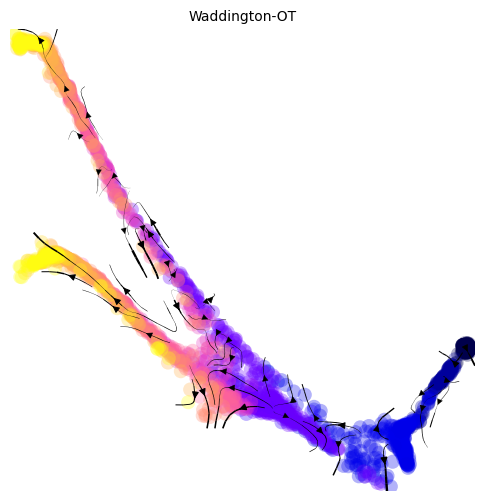

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`       

  0%|          | 0/11 [00:00<?, ?time pair/s]

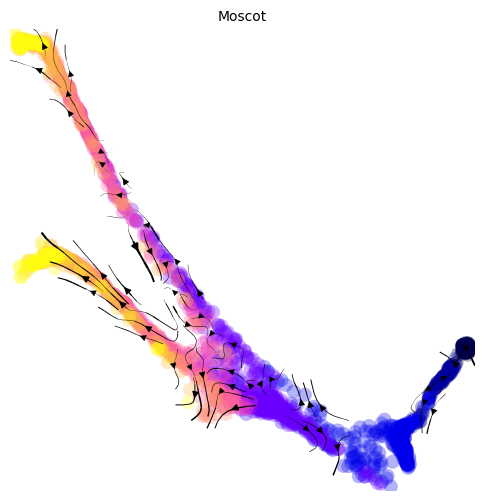

In [9]:
import moscot as mt
import wot
ot_model = wot.ot.OTModel(adata_wot, day_field="numerical_time")
ot_model.compute_all_transport_maps(tmap_out="zebrafish/wot/")
rtk = cr.kernels.RealTimeKernel.from_wot(adata_wot, path="zebrafish/wot/", time_key="numerical_time")
rtk = rtk.compute_transition_matrix()
rtk.plot_projection(basis="force_directed",connectivities=adata_wot.obsp["connectivities"],color="Stage",legend_loc="none",frameon=False,show=False,title="Waddington-OT",figsize=(6,6))
ax = plt.gca()
ax.grid(False)
plt.show()

problem = mt.problems.TemporalProblem(adata_moscot)
problem = problem.prepare(time_key="numerical_time").solve()
rtk = cr.kernels.RealTimeKernel.from_moscot(problem)
rtk = rtk.compute_transition_matrix()
rtk.plot_projection(basis="force_directed",connectivities=adata_moscot.obsp["connectivities"],color="Stage",legend_loc="none", frameon=False,show=False,title="Moscot",figsize=(6,6))
ax = plt.gca()
ax.grid(False)
plt.show()

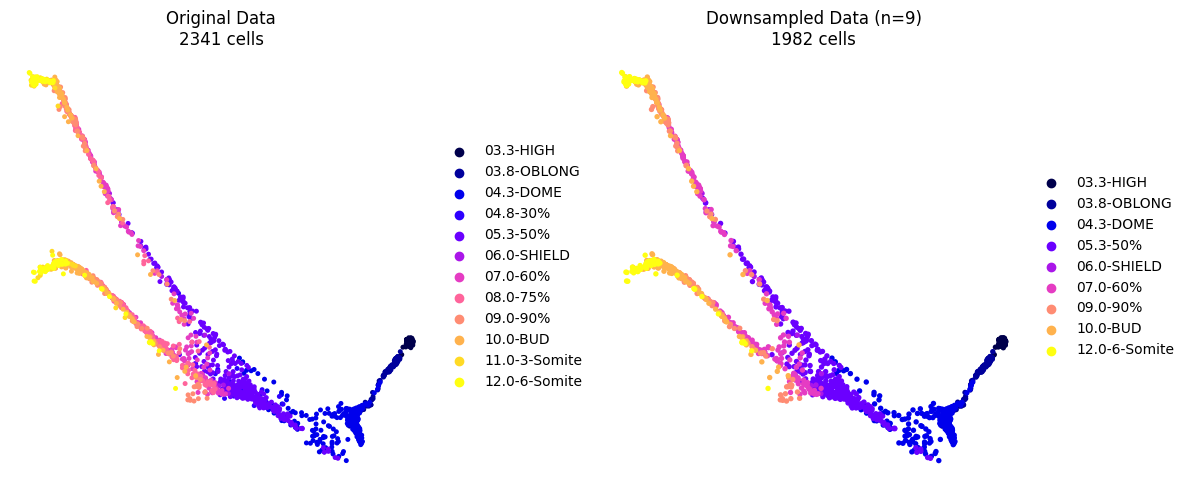

Downsampled data (n=9).
Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.857878,trend_loss=0.846854,time_loss=0.110241
epoch  51:loss=0.363848,trend_loss=0.362828,time_loss=0.010201
epoch 101:loss=0.330962,trend_loss=0.330150,time_loss=0.008122
epoch 151:loss=0.315494,trend_loss=0.314763,time_loss=0.007304
epoch 201:loss=0.311762,trend_loss=0.311053,time_loss=0.007094
epoch 251:loss=0.305885,trend_loss=0.305207,time_loss=0.006778
epoch 301:loss=0.299478,trend_loss=0.298835,time_loss=0.006433
Early stopping at epoch 343


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


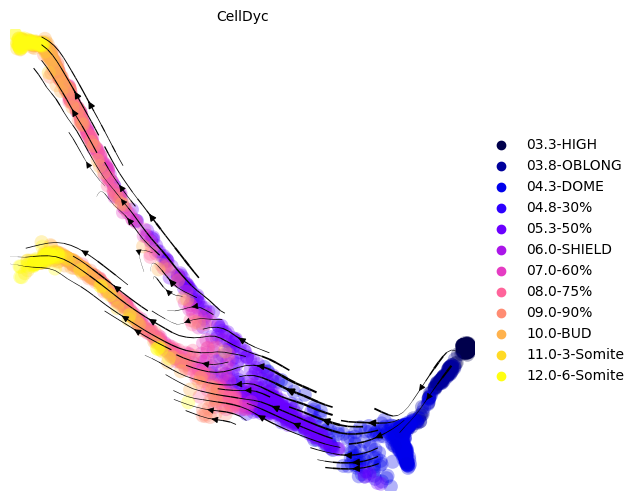

computing velocity embedding
finished.


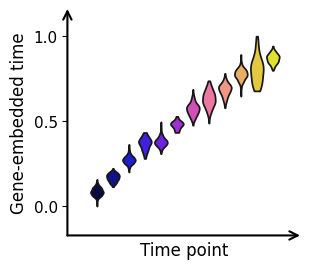

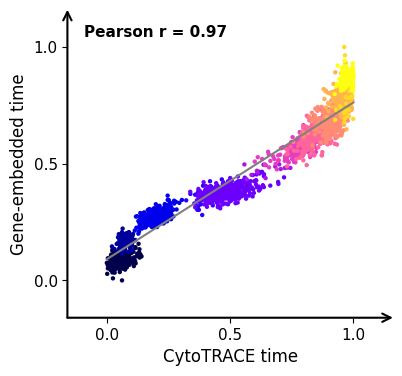

In [11]:
keep = 9
adata = cdc.datasets.zebrafish()
cat_map = {'03.3-HIGH': 03.3,
           '03.8-OBLONG': 03.8,
           '04.3-DOME': 04.3,
           '04.8-30%':04.8,
           '05.3-50%':05.3,
           '06.0-SHIELD':06.0,
           '07.0-60%':07.0,
           '08.0-75%':08.0,
           '09.0-90%':09.0,
           '10.0-BUD':10.0,
           '11.0-3-Somite':11.0,
           '12.0-6-Somite':12.0}
adata.obs['numerical_time'] = adata.obs['Stage'].map(cat_map).astype('category')
adata.obs['ct_pseudotime'] = adata_ct.obs['ct_pseudotime']
adata_sub = cdc.rp.reduce_timepoint(adata.copy(),
                         time_key='numerical_time',
                         num=keep,
                         color='Stage',
                         basis='force_directed')
cdc.tl.recover_dyc(adata_sub,time_key="numerical_time", save_path=f'zebrafish_{keep}.pt')
adata = cdc.tl.preprocess(adata)
cdc.tl.recover_dyc(adata, time_key='numerical_time', model_path=f'zebrafish_{keep}.pt')
cdc.pl.plot_velocity_projection(adata,basis='force_directed', color='Stage', legend_loc='right',figsize=(6,6),title="CellDyc")
cdc.pl.getime_violin(adata, 'getime', 'numerical_time',palette='gnuplot2')
cdc.pl.getime_correlation(adata, 'ct_pseudotime','getime','Stage', palette='gnuplot2',xlabel="CytoTRACE time",ylabel="Gene-embedded time",xticks=True)

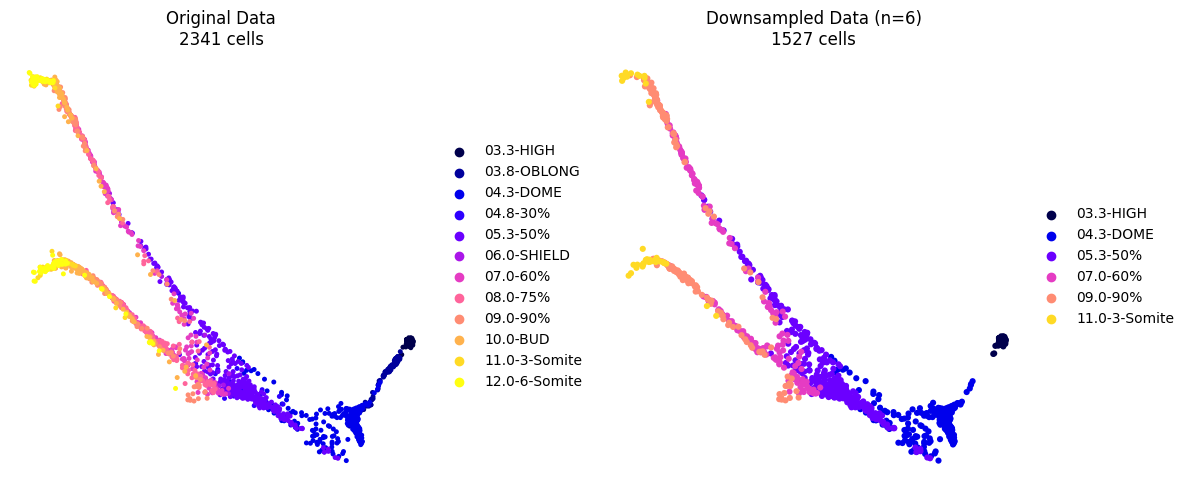

Downsampled data (n=6).
Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.876759,trend_loss=0.862731,time_loss=0.140287
epoch  51:loss=0.313247,trend_loss=0.312212,time_loss=0.010346
epoch 101:loss=0.270490,trend_loss=0.269659,time_loss=0.008309
epoch 151:loss=0.259464,trend_loss=0.258694,time_loss=0.007700
epoch 201:loss=0.244994,trend_loss=0.244285,time_loss=0.007091
epoch 251:loss=0.245265,trend_loss=0.244603,time_loss=0.006618
Early stopping at epoch 256


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


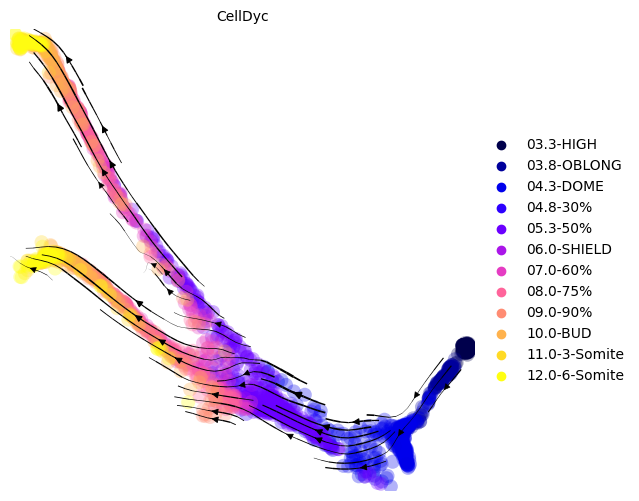

computing velocity embedding
finished.


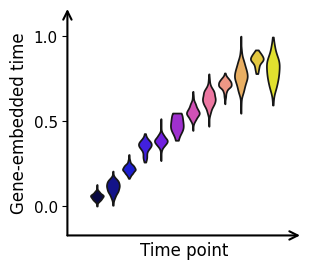

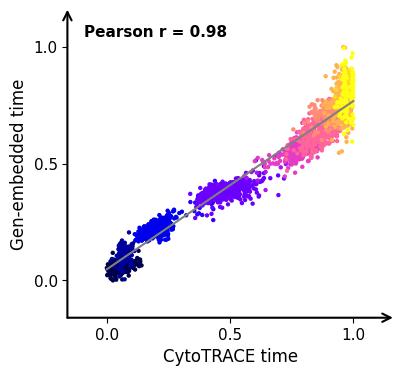

In [12]:
keep = 6
adata = cdc.datasets.zebrafish()
cat_map = {'03.3-HIGH': 03.3,
           '03.8-OBLONG': 03.8,
           '04.3-DOME': 04.3,
           '04.8-30%':04.8,
           '05.3-50%':05.3,
           '06.0-SHIELD':06.0,
           '07.0-60%':07.0,
           '08.0-75%':08.0,
           '09.0-90%':09.0,
           '10.0-BUD':10.0,
           '11.0-3-Somite':11.0,
           '12.0-6-Somite':12.0}
adata.obs['numerical_time'] = adata.obs['Stage'].map(cat_map).astype('category')
adata.obs['ct_pseudotime'] = adata_ct.obs['ct_pseudotime']
adata_sub = cdc.rp.reduce_timepoint(adata.copy(),
                         time_key='numerical_time',
                         num=keep,
                         color='Stage',
                         basis='force_directed')
cdc.tl.recover_dyc(adata_sub,time_key="numerical_time", save_path=f'zebrafish_{keep}.pt')
adata = cdc.tl.preprocess(adata)
cdc.tl.recover_dyc(adata, time_key='numerical_time', model_path=f'zebrafish_{keep}.pt')
cdc.pl.plot_velocity_projection(adata,basis='force_directed', color='Stage', legend_loc='right',figsize=(6,6),title="CellDyc")
cdc.pl.getime_violin(adata, 'getime', 'numerical_time',palette='gnuplot2')
cdc.pl.getime_correlation(adata, 'ct_pseudotime','getime','Stage', palette='gnuplot2',xlabel="CytoTRACE time",ylabel="Gen-embedded time",xticks=True)

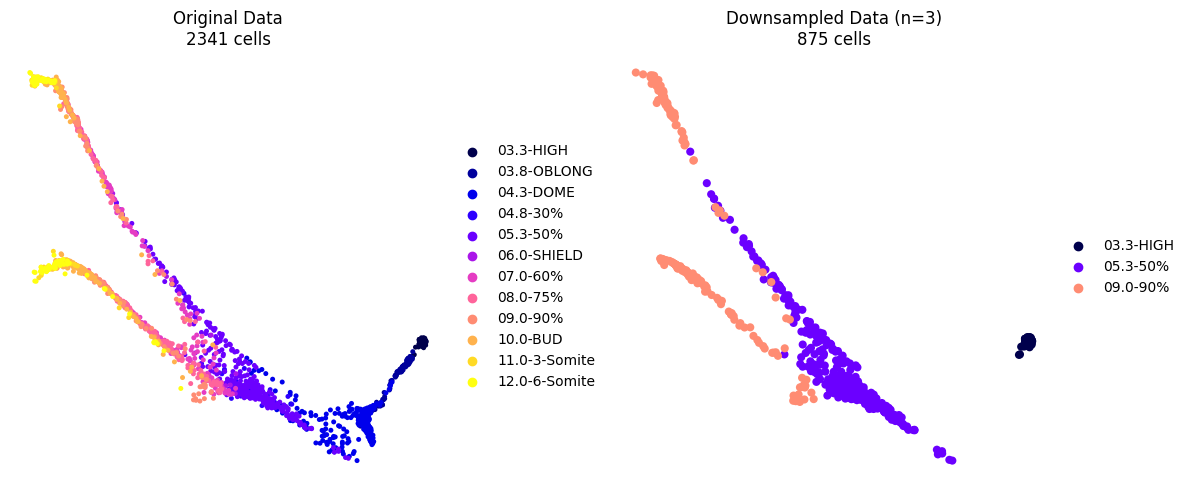

Downsampled data (n=3).
Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.980861,trend_loss=0.964771,time_loss=0.160895
epoch  51:loss=0.193777,trend_loss=0.193061,time_loss=0.007164
epoch 101:loss=0.142490,trend_loss=0.141966,time_loss=0.005235
epoch 151:loss=0.113535,trend_loss=0.113014,time_loss=0.005213
Early stopping at epoch 192


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


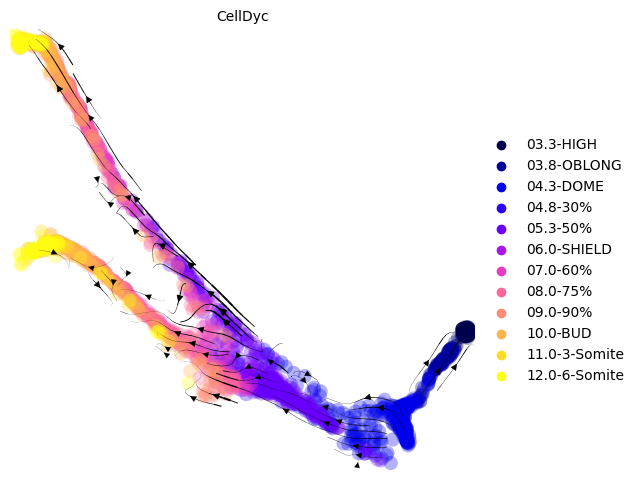

computing velocity embedding
finished.


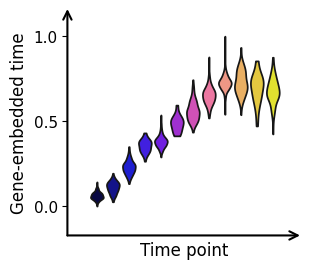

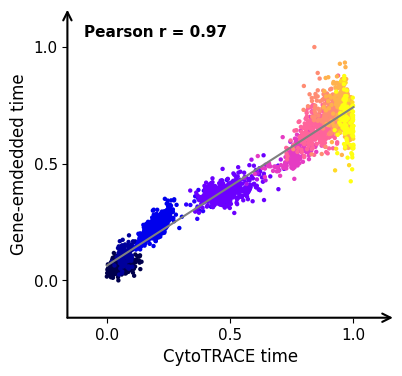

In [13]:
keep = 3
adata = cdc.datasets.zebrafish()
cat_map = {'03.3-HIGH': 03.3,
           '03.8-OBLONG': 03.8,
           '04.3-DOME': 04.3,
           '04.8-30%':04.8,
           '05.3-50%':05.3,
           '06.0-SHIELD':06.0,
           '07.0-60%':07.0,
           '08.0-75%':08.0,
           '09.0-90%':09.0,
           '10.0-BUD':10.0,
           '11.0-3-Somite':11.0,
           '12.0-6-Somite':12.0}
adata.obs['numerical_time'] = adata.obs['Stage'].map(cat_map).astype('category')
adata.obs['ct_pseudotime'] = adata_ct.obs['ct_pseudotime']
adata_sub = cdc.rp.reduce_timepoint(adata.copy(),
                         time_key='numerical_time',
                         num=keep,
                         color='Stage',
                         basis='force_directed')
cdc.tl.recover_dyc(adata_sub,time_key="numerical_time", save_path=f'zebrafish_{keep}.pt')
adata = cdc.tl.preprocess(adata)
cdc.tl.recover_dyc(adata, time_key='numerical_time', model_path=f'zebrafish_{keep}.pt')
cdc.pl.plot_velocity_projection(adata,basis='force_directed', color='Stage', legend_loc='right',figsize=(6,6),title="CellDyc")
cdc.pl.getime_violin(adata, 'getime', 'numerical_time',palette='gnuplot2')
cdc.pl.getime_correlation(adata, 'ct_pseudotime','getime','Stage', palette='gnuplot2',xlabel="CytoTRACE time",ylabel="Gene-emdedded time",xticks=True)